In [1]:
# read file

import pickle  # type: ignore[reportMissingImports]
import sys
import types
from pathlib import Path  # type: ignore[reportMissingImports]

# 1) Pick the exact file to load
# LiH 8-qubit active-space case generated in Pauli_Ham
file_name = "LiH_active8_scan_bond_1.596_active_1-2-4-5_q8_of.pkl"

# 2) Resolve Pauli_Ham folder based on runtime
try:
    import google.colab  # type: ignore[reportMissingImports]
    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Keep your original Google Drive path behavior in Colab
    save_folder = Path('/content/drive/My Drive/Quantum_chemistry/pauli_Ham')
else:
    # Local fallback: prefer ./Pauli_Ham, then ../Pauli_Ham
    cwd = Path.cwd()
    local_candidates = [cwd / 'Pauli_Ham', cwd.parent / 'Pauli_Ham']
    save_folder = next((p for p in local_candidates if p.exists()), local_candidates[0])

file_path = save_folder / file_name


class PauliSumOpShim:
    """Compatibility shim for loading old qiskit.opflow pickles."""

    def __init__(self, *args, **kwargs):
        pass


def install_qiskit_opflow_shim() -> None:
    """Provide legacy qiskit.opflow module path for pickle loading."""
    module_name = 'qiskit.opflow.primitive_ops.pauli_sum_op'

    # Rebind every run so class identity remains consistent across reruns.
    opflow_module = sys.modules.get('qiskit.opflow', types.ModuleType('qiskit.opflow'))
    primitive_ops_module = sys.modules.get(
        'qiskit.opflow.primitive_ops',
        types.ModuleType('qiskit.opflow.primitive_ops')
    )
    pauli_sum_op_module = sys.modules.get(module_name, types.ModuleType(module_name))
    pauli_sum_op_module.PauliSumOp = PauliSumOpShim

    sys.modules['qiskit.opflow'] = opflow_module
    sys.modules['qiskit.opflow.primitive_ops'] = primitive_ops_module
    sys.modules[module_name] = pauli_sum_op_module


def to_sparse_pauli_op(operator):
    """Normalize loaded Hamiltonians to qiskit's SparsePauliOp."""
    from qiskit.quantum_info import SparsePauliOp  # type: ignore[reportMissingImports]

    # Legacy qiskit.opflow object
    if hasattr(operator, '_primitive'):
        operator = operator._primitive

    # Already in the expected format
    if isinstance(operator, SparsePauliOp):
        return operator

    # OpenFermion QubitOperator -> SparsePauliOp
    if hasattr(operator, 'terms'):
        n_qubits = 0
        for term in operator.terms:
            for qubit_idx, _ in term:
                n_qubits = max(n_qubits, qubit_idx + 1)

        pauli_terms = []
        for term, coeff in operator.terms.items():
            label = ['I'] * n_qubits
            for qubit_idx, pauli in term:
                # Qiskit labels are ordered q_(n-1) ... q_0
                label[n_qubits - 1 - qubit_idx] = pauli
            pauli_terms.append((''.join(label), complex(coeff)))

        return SparsePauliOp.from_list(pauli_terms).simplify()

    raise TypeError(f'Unsupported Hamiltonian type: {type(operator)}')


# 3) Load the object
if file_path.exists():
    install_qiskit_opflow_shim()

    with file_path.open('rb') as file:
        H_qubit_loaded = pickle.load(file)

    H_qubit_loaded = to_sparse_pauli_op(H_qubit_loaded)

    print('--- Hamiltonian Loaded Successfully ---')
    print(f"Runtime: {'Google Colab' if in_colab else 'Local'}")
    print(f'Folder: {save_folder}')
    print(f'File: {file_name}')
    print(f'Number of qubits: {H_qubit_loaded.num_qubits}')
    print(f'Number of Pauli terms: {len(H_qubit_loaded)}')
    print(f'Object type: {type(H_qubit_loaded)}')
else:
    print(f'Error: File not found: {file_path}')
    if save_folder.exists():
        pkl_files = sorted(p.name for p in save_folder.glob('*.pkl'))
        print('Available .pkl files in folder:')
        for name in pkl_files:
            print(f'  - {name}')
    else:
        print('Pauli_Ham folder was not found in expected locations.')


--- Hamiltonian Loaded Successfully ---
Runtime: Local
Folder: /Users/zacharyhe/cross_chips_sim/Pauli_Ham
File: LiH_active8_scan_bond_1.596_active_1-2-4-5_q8_of.pkl
Number of qubits: 8
Number of Pauli terms: 193
Object type: <class 'qiskit.quantum_info.operators.symplectic.sparse_pauli_op.SparsePauliOp'>


Number of parameters: 2


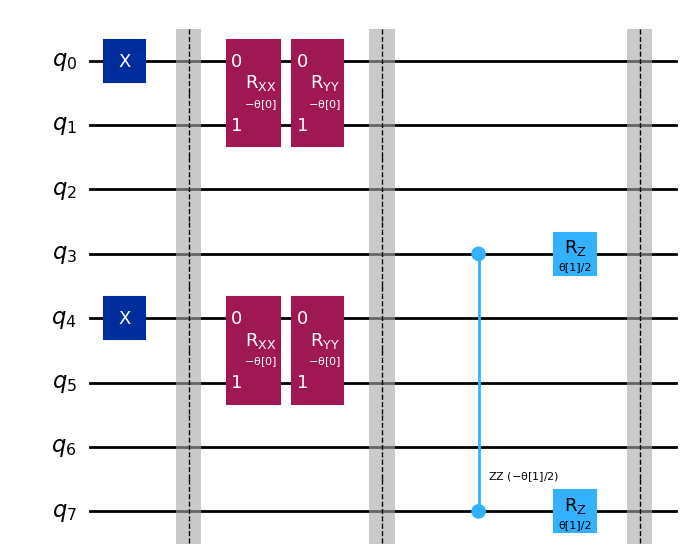

In [2]:
from qiskit import QuantumCircuit  # type: ignore[reportMissingImports]
from qiskit.circuit import ParameterVector  # type: ignore[reportMissingImports]

def givens_block_fermionic(qc, theta, q1, q2):
    """
    Implements: exp[ i * theta * (c^\dagger_1 c_2 + c^\dagger_2 c_1) ]
    Assumes q1 and q2 are adjacent qubits.
    """
    qc.rxx(-theta, q1, q2)
    qc.ryy(-theta, q1, q2)

def onsite_block(qc, phi, q_alpha, q_beta):
    """ZZ interaction (O block) between opposite spin orbitals."""
    qc.rzz(-phi / 2, q_alpha, q_beta)
    qc.rz(phi / 2, q_alpha)
    qc.rz(phi / 2, q_beta)

def build_hopping_onsite_pool(num_spatial_orbitals):
    """
    Build fixed operator pool of size 2N-1:
      - N-1 hopping operators H_i between (i, i+1) in alpha and beta sectors (shared theta)
      - N onsite operators O_i between (i_alpha, i_beta)
    """
    pool = []
    for i in range(num_spatial_orbitals - 1):
        pool.append(("hopping", i))
    for i in range(num_spatial_orbitals):
        pool.append(("onsite", i))
    return pool

def pool_op_label(op, num_spatial_orbitals=4):
    kind, idx = op
    if kind == "hopping":
        # Explicit spin-conserving pair: alpha(i,j) + beta(i+N,j+N)
        i = idx
        j = i + 1
        return f"Hαβ({i},{j}|{i + num_spatial_orbitals},{j + num_spatial_orbitals})"
    return f"O({idx})"

def apply_pool_operator(qc, theta, op, num_spatial_orbitals):
    kind, idx = op
    if kind == "hopping":
        i = idx
        j = i + 1
        if not (0 <= i < num_spatial_orbitals - 1):
            raise ValueError(f"Invalid hopping index {i} for N={num_spatial_orbitals}")

        # Spin conservation enforced: if alpha hop (i,j) is selected,
        # the corresponding beta hop (i+N, j+N) is always applied too.
        givens_block_fermionic(qc, theta, i, j)
        givens_block_fermionic(qc, theta, i + num_spatial_orbitals, j + num_spatial_orbitals)
    elif kind == "onsite":
        i = idx
        onsite_block(qc, theta, i, i + num_spatial_orbitals)
    else:
        raise ValueError(f"Unknown operator kind: {kind}")

def prepare_pool_ansatz(num_spatial_orbitals, op_sequence, initial_occupied=(0, 4)):
    """Build ansatz from selected operator sequence (one parameter per selected operator)."""
    num_qubits = 2 * num_spatial_orbitals
    qc = QuantumCircuit(num_qubits)

    params = ParameterVector("θ", length=len(op_sequence))

    for i in initial_occupied:
        qc.x(i)
    qc.barrier()

    for p_idx, op in enumerate(op_sequence):
        apply_pool_operator(qc, params[p_idx], op, num_spatial_orbitals)
        qc.barrier()

    return qc, params

# --- Test Case ---
num_spatial_orbitals_demo = 4
pool_demo = build_hopping_onsite_pool(num_spatial_orbitals_demo)
example_op_sequence = [pool_demo[0], pool_demo[-1]]
ansatz, ansatz_params = prepare_pool_ansatz(
    num_spatial_orbitals=num_spatial_orbitals_demo,
    op_sequence=example_op_sequence,
)
print(f"Number of parameters: {ansatz.num_parameters}")

# Draw the circuit
ansatz.draw("mpl")


In [3]:
import numpy as np  # type: ignore[reportMissingImports]
from qiskit.primitives import StatevectorEstimator as Estimator  # type: ignore[reportMissingImports]

# 1. Setup the Estimator
estimator = Estimator()

def compute_vqe_energy(params, ansatz, hamiltonian):
    """Core function to measure the energy for a specific parameter vector."""
    pub = (ansatz, hamiltonian, params)
    job = estimator.run([pub])
    result = job.result()
    energy = result[0].data.evs
    return float(energy)

num_spatial_orbitals = 4  # 8 qubits total
num_cycles_for_check = 10

# Reference sequence: full (2N-1) pool repeated for several cycles.
pool_for_check = build_hopping_onsite_pool(num_spatial_orbitals)
reference_op_sequence = pool_for_check * num_cycles_for_check

ansatz, ansatz_params = prepare_pool_ansatz(
    num_spatial_orbitals,
    reference_op_sequence,
)
print(f"Number of parameters: {ansatz.num_parameters}")
hamiltonian = H_qubit_loaded

# Test at zero parameters
params_zeros = np.zeros(ansatz.num_parameters)
energy_zero = compute_vqe_energy(params_zeros, ansatz, hamiltonian)

# Test at a second point (currently same value for sanity check)
params_random = np.zeros(ansatz.num_parameters)
energy_random = compute_vqe_energy(params_random, ansatz, hamiltonian)

print("--- Energy Check ---")
print(f"Parameters (Zeros)  Energy: {energy_zero:.12f}")
print(f"Parameters (Random) Energy: {energy_random:.12f}")


Number of parameters: 70
--- Energy Check ---
Parameters (Zeros)  Energy: -7.861992688741
Parameters (Random) Energy: -7.861992688741


In [4]:
import numpy as np  # type: ignore[reportMissingImports]
from qiskit.quantum_info import Statevector, state_fidelity  # type: ignore[reportMissingImports]

def get_exact_ground_state(hamiltonian):
    """
    Diagonalizes the Hamiltonian to find the exact ground state energy and statevector.
    """
    # 1. Convert the Qiskit operator to a dense numpy matrix
    ham_matrix = hamiltonian.to_matrix()

    # 2. Diagonalize the Hamiltonian matrix (eigh is for Hermitian matrices)
    eigenvalues, eigenvectors = np.linalg.eigh(ham_matrix)

    # 3. Extract the lowest energy and corresponding eigenvector
    exact_energy = eigenvalues[0]
    exact_gs_array = eigenvectors[:, 0]

    # 4. Convert it to a Qiskit Statevector
    exact_gs_statevector = Statevector(exact_gs_array)

    return exact_energy, exact_gs_statevector


def get_fidelity(state_1, state_2):
    """
    Calculates the fidelity between two quantum states.
    """
    # Compute the squared overlap |<state_1 | state_2>|^2
    fidelity = state_fidelity(state_1, state_2)
    return fidelity


# --- Usage ---

# 1. Get the exact ground state and energy
exact_energy, exact_gs_statevector = get_exact_ground_state(hamiltonian)


In [5]:
import numpy as np
from types import SimpleNamespace
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

class VQETracker:
    def __init__(self, ansatz, hamiltonian, estimator):
        self.ansatz = ansatz
        self.hamiltonian = hamiltonian
        self.estimator = estimator
        self.gradient = ParamShiftEstimatorGradient(self.estimator)
        self.energy_history = []
        self.grad_norm_history = []
        self.last_grad_norm = 0.0
        self.last_energy = 0.0
        self.total_measurements = 0
        self.energy_meas_this_iter = 0
        self.gradient_meas_this_iter = 0

    def objective(self, params):
        pub = (self.ansatz, self.hamiltonian, params)
        job = self.estimator.run([pub])
        result = job.result()
        energy = float(result[0].data.evs)

        self.energy_meas_this_iter += 1
        self.total_measurements += 1
        self.last_energy = energy
        return energy

    def gradient_func(self, params):
        gradient_job = self.gradient.run([self.ansatz], [self.hamiltonian], [params])
        gradient_result = gradient_job.result()
        grad = np.asarray(gradient_result.gradients[0], dtype=float)

        num_params = len(params)
        self.gradient_meas_this_iter += 2 * num_params
        self.total_measurements += 2 * num_params
        self.last_grad_norm = np.linalg.norm(grad)
        return grad

def run_adam(
    tracker,
    x0,
    maxiter=1000,
    lr=1,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    grad_tol=1e-8,
):
    params = np.array(x0, dtype=float)
    m = np.zeros_like(params)
    v = np.zeros_like(params)

    if params.size == 0:
        energy = tracker.objective(params)
        tracker.last_grad_norm = 0.0
        return SimpleNamespace(x=params, fun=energy, success=True, nit=0)

    for t in range(1, maxiter + 1):
        grad = tracker.gradient_func(params)
        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)
        m_hat = m / (1.0 - beta1**t)
        v_hat = v / (1.0 - beta2**t)
        params -= lr * m_hat / (np.sqrt(v_hat) + eps)

        energy = tracker.objective(params)
        if tracker.last_grad_norm < grad_tol:
            break

    return SimpleNamespace(
        x=params,
        fun=energy,
        success=tracker.last_grad_norm < grad_tol,
        nit=t,
    )

from qiskit.quantum_info import Statevector


def pool_ansatz_energy(
    num_spatial_orbitals,
    op_sequence,
    params,
    hamiltonian,
    initial_occupied=(0, 4),
):
    """Energy of the current evolved circuit |psi(op_sequence, params)>."""
    params = np.asarray(params, dtype=float)
    num_qubits = 2 * num_spatial_orbitals

    if len(op_sequence) == 0:
        qc = QuantumCircuit(num_qubits)
        for i in initial_occupied:
            qc.x(i)
        sv = Statevector(qc)
        return float(np.real(sv.expectation_value(hamiltonian)))

    qc, pvec = prepare_pool_ansatz(
        num_spatial_orbitals,
        op_sequence,
        initial_occupied=initial_occupied,
    )
    bind = {pvec[i]: float(params[i]) for i in range(len(params))}
    sv = Statevector(qc.assign_parameters(bind))
    return float(np.real(sv.expectation_value(hamiltonian)))


def score_pool_gradients(
    num_spatial_orbitals,
    op_sequence,
    current_params,
    operator_pool,
    hamiltonian,
    estimator,
    initial_occupied=(0, 1, 4, 5),
    grad_probe=1e-2,
):
    """
    Score each pool operator from the *current evolved state* with robust finite-difference.

    |psi> = U(op_sequence, current_params) |HF>
    For candidate A, append A and estimate:
      dE/dtheta |_{theta=0} ~= (E(+probe) - E(-probe)) / (2*probe)
    """
    current_params = np.asarray(current_params, dtype=float)
    pool_grads = []

    for op in operator_pool:
        trial_sequence = list(op_sequence) + [op]
        trial_ansatz, _ = prepare_pool_ansatz(
            num_spatial_orbitals,
            trial_sequence,
            initial_occupied=initial_occupied,
        )

        trial_plus = np.concatenate([current_params, np.array([+grad_probe], dtype=float)])
        trial_minus = np.concatenate([current_params, np.array([-grad_probe], dtype=float)])

        e_plus = compute_vqe_energy(trial_plus, trial_ansatz, hamiltonian)
        e_minus = compute_vqe_energy(trial_minus, trial_ansatz, hamiltonian)

        grad_fd = (e_plus - e_minus) / (2.0 * grad_probe)
        pool_grads.append(float(grad_fd))

    return np.asarray(pool_grads, dtype=float)

def run_adapt_pool_vqe(
    num_spatial_orbitals,
    hamiltonian,
    estimator,
    num_ops_to_pick=10,
    adam_maxiter=100,
    adam_lr=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    adam_eps=1e-8,
    adam_grad_tol=1e-8,
    initial_occupied=(0, 1, 4, 5),
    grad_probe=1e-2,
    op_init_scale=1e-2,
    flat_grad_tol=1e-12,
):
    """
    ADAPT loop (pick -> evolve -> pick from new state):
      1) Score all pool ops from the current optimized |psi>.
      2) Pick one operator and append it at theta=0.
      3) VQE-optimize all parameters (evolve |psi>).
      4) Repeat.
    """
    operator_pool = build_hopping_onsite_pool(num_spatial_orbitals)
    op_sequence = []
    current_params = np.array([], dtype=float)
    logs = []
    cumulative_measurements = 0
    last_chosen_idx = None

    print("\n--- Starting Operator-Pool ADAPT Optimization ---")
    print(
        f"Operator pool (2N-1={len(operator_pool)}): "
        f"{[pool_op_label(op, num_spatial_orbitals) for op in operator_pool]}"
    )
    print(f"Initial occupied orbitals: {initial_occupied}")
    print(f"Gradient probe: {grad_probe:.3e}, op init scale: {op_init_scale:.3e}")
    print("Flow each iteration: score from evolved |psi> -> pick 1 op -> VQE evolve -> repeat")

    for step in range(num_ops_to_pick):
        energy_before = pool_ansatz_energy(
            num_spatial_orbitals,
            op_sequence,
            current_params,
            hamiltonian,
            initial_occupied=initial_occupied,
        )

        pool_grads = score_pool_gradients(
            num_spatial_orbitals=num_spatial_orbitals,
            op_sequence=op_sequence,
            current_params=current_params,
            operator_pool=operator_pool,
            hamiltonian=hamiltonian,
            estimator=estimator,
            initial_occupied=initial_occupied,
            grad_probe=grad_probe,
        )

        print(
            f"\nIteration {step + 1:2d} | evolved state: "
            f"E={energy_before:.12f}, n_ops={len(op_sequence)}, "
            f"theta={np.round(current_params, 6) if current_params.size else '[]'}"
        )
        print("  Pool gradients from this state (append each candidate at theta=0):")
        ranking = np.argsort(-np.abs(pool_grads))
        for idx, op in enumerate(operator_pool):
            rank_pos = int(np.where(ranking == idx)[0][0]) + 1
            print(
                f"    {idx:2d} {pool_op_label(op, num_spatial_orbitals):>24s} : {pool_grads[idx]: .10e}  "
                f"(rank {rank_pos}/{len(operator_pool)})"
            )

        candidate_indices = [i for i in range(len(operator_pool)) if i != last_chosen_idx]
        if not candidate_indices:
            # Degenerate case: pool has one operator only.
            candidate_indices = [0]

        candidate_abs_grads = np.abs(pool_grads[candidate_indices])
        max_abs_grad = float(np.max(candidate_abs_grads))
        if max_abs_grad < flat_grad_tol:
            # If gradients are flat, diversify among currently allowed candidates.
            chosen_idx = candidate_indices[step % len(candidate_indices)]
            print(
                f"  Warning: flat allowed pool gradients (max |g|={max_abs_grad:.3e}); "
                f"fallback pick idx={chosen_idx}"
            )
        else:
            chosen_idx = int(candidate_indices[int(np.argmax(candidate_abs_grads))])

        chosen_op = operator_pool[chosen_idx]
        chosen_grad = float(pool_grads[chosen_idx])
        last_chosen_idx = chosen_idx

        op_sequence.append(chosen_op)
        ansatz_dynamic, _ = prepare_pool_ansatz(
            num_spatial_orbitals,
            op_sequence,
            initial_occupied=initial_occupied,
        )

        # Initialize new parameter with a small signed seed for easier symmetry breaking.
        signed_seed = op_init_scale * (1.0 if chosen_grad >= 0.0 else -1.0)
        current_params = np.concatenate([current_params, np.array([signed_seed], dtype=float)])

        tracker = VQETracker(ansatz_dynamic, hamiltonian, estimator)
        result = run_adam(
            tracker,
            current_params,
            maxiter=adam_maxiter,
            lr=adam_lr,
            beta1=adam_beta1,
            beta2=adam_beta2,
            eps=adam_eps,
            grad_tol=adam_grad_tol,
        )

        current_params = np.asarray(result.x, dtype=float)
        cumulative_measurements += tracker.total_measurements

        energy_after = pool_ansatz_energy(
            num_spatial_orbitals,
            op_sequence,
            current_params,
            hamiltonian,
            initial_occupied=initial_occupied,
        )

        log_entry = {
            "iteration": step + 1,
            "energy_before": energy_before,
            "energy_after": energy_after,
            "delta_energy": energy_after - energy_before,
            "chosen_index": chosen_idx,
            "chosen_label": pool_op_label(chosen_op, num_spatial_orbitals),
            "chosen_grad": chosen_grad,
            "thetas": current_params.copy(),
            "num_parameters": ansatz_dynamic.num_parameters,
            "cumulative_measurements": cumulative_measurements,
        }
        logs.append(log_entry)

        print(
            f"  Selected {log_entry['chosen_label']} (idx={chosen_idx}, grad={chosen_grad:.6e})"
        )
        print(
            f"  After VQE evolution: E={energy_after:.12f} "
            f"(dE={log_entry['delta_energy']:+.3e}), "
            f"|theta|_max={np.max(np.abs(current_params)):.6e}, "
            f"theta={np.round(current_params, 6)}"
        )

    return SimpleNamespace(
        ansatz=ansatz_dynamic,
        params=current_params,
        selected_ops=op_sequence,
        logs=logs,
        final_energy=logs[-1]["energy_after"] if logs else np.nan,
        total_measurements=cumulative_measurements,
        operator_pool=operator_pool,
    )

# User knobs
num_spatial_orbitals = 4
num_ops_to_pick = 10   # one pick per iteration; 10 total picks
initial_occupied = (0, 4)

adapt_result = run_adapt_pool_vqe(
    num_spatial_orbitals=num_spatial_orbitals,
    hamiltonian=hamiltonian,
    estimator=estimator,
    num_ops_to_pick=num_ops_to_pick,
    adam_maxiter=100,
    adam_lr=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    adam_eps=1e-8,
    adam_grad_tol=1e-8,
    initial_occupied=initial_occupied,
    grad_probe=1e-2,
    op_init_scale=1e-2,
    flat_grad_tol=1e-12,
)

ansatz = adapt_result.ansatz
optimized_params = adapt_result.params

print("\n--- Operator-Pool ADAPT Complete ---")
print(f"Picked ops: {len(adapt_result.selected_ops)}")
print(f"Selected sequence: {[pool_op_label(op, num_spatial_orbitals) for op in adapt_result.selected_ops]}")
print(f"Final parameter count: {ansatz.num_parameters}")
print(f"Final optimized energy: {adapt_result.final_energy:.12f}")
print(f"Final total measurements: {adapt_result.total_measurements}")



--- Starting Operator-Pool ADAPT Optimization ---
Operator pool (2N-1=7): ['Hαβ(0,1|4,5)', 'Hαβ(1,2|5,6)', 'Hαβ(2,3|6,7)', 'O(0)', 'O(1)', 'O(2)', 'O(3)']
Initial occupied orbitals: (0, 4)
Gradient probe: 1.000e-02, op init scale: 1.000e-02
Flow each iteration: score from evolved |psi> -> pick 1 op -> VQE evolve -> repeat

Iteration  1 | evolved state: E=-7.861992688741, n_ops=0, theta=[]
  Pool gradients from this state (append each candidate at theta=0):
     0             Hαβ(0,1|4,5) :  0.0000000000e+00  (rank 1/7)
     1             Hαβ(1,2|5,6) :  0.0000000000e+00  (rank 2/7)
     2             Hαβ(2,3|6,7) :  0.0000000000e+00  (rank 3/7)
     3                     O(0) :  0.0000000000e+00  (rank 4/7)
     4                     O(1) :  0.0000000000e+00  (rank 5/7)
     5                     O(2) :  0.0000000000e+00  (rank 6/7)
     6                     O(3) :  0.0000000000e+00  (rank 7/7)
  Selected Hαβ(0,1|4,5) (idx=0, grad=0.000000e+00)
  After VQE evolution: E=-7.86198127375

KeyboardInterrupt: 